# Sliding Window Analysis (and general ENSO Characteristics)

Notebook for making basic visualizations of ENSO (and other timeseries).

Contents

1. Load Nino3.4 Indices from netCDF
2. Monthly Standard Deviation
3. Sliding Window Standard Deviation and Persistence

by Glenn Liu, 2026.01.14


In [11]:
import sys
import time
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
import xarray as xr
import sys
import tqdm
import glob 
import scipy as sp
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import calendar as cal

# Loading Required Datasets

In [16]:
# Load a NetCDF containing standardized ENSO index and the standard deviation

# Experiment Names
expnames          = ["TCo319-DART-ctl1950d-gibbs-charn","TCo319-DART-ssp585d-gibbs-charn","TCo1279-DART-2060"]
expcolors         = ["grey","salmon","midnightblue"] # Color Associated with each experiment

# File Information
ensopath          = "/home/niu4/gliu8/projects/scrap/nino34/" # (!!) Set Path to ENSO Indices
ensoid_name       = "nino34" # Name of ENSO Index
standardize       = False # Set to True to return standardized ENSO Indices

# Load the Files
nexp = len(expnames)
enso_indices = []
for ex in range(nexp): 
    expname           = expnames[ex]    
    enso_nc           = "%s%s_%s.nc" % (ensopath,expname,ensoid_name) # ex: <path_to_file>/TCo1279-DART-2060_nino34.nc
    print("Loading the following file: %s" % enso_nc)

    sc

# # Indicate Experiment Name
# expnames        = [
#                    "TCo319_ctl1950d",
#                    "TCo319-DART-ctl1950d-gibbs-charn",
#                    "TCo319_ssp585",
#                    "TCo319-DART-ssp585d-gibbs-charn",
#                    "TCo1279-DART-1950",
#                    "TCo1279-DART-2060",
#                    "TCo1279-DART-2090",
#                    "TCo2559-DART-1950C",
#                    "ERA5_1979_2024",
#                   ]

# # Experiment Long Name (for plotting)
# expnames_long   = [
#                    "31km Control",
#                    "31km Control (GibbsFree and Charnock)",
#                    "31km SSP585",
#                    "31km SSP585 (GibbsFree and Charnock)",
#                    "9km 1950",
#                    "9km 2060",
#                    "9km 2090",
#                    "4km 1950",
#                    "ERA5",
#                   ]


Loading the following file: /home/niu4/gliu8/projects/scrap/nino34/TCo319-DART-ctl1950d-gibbs-charn_nino34.nc
<xarray.Dataset> Size: 11kB
Dimensions:  (time: 660)
Coordinates:
  * time     (time) datetime64[ns] 5kB 1950-01-16T12:00:00 ... 2004-12-16T12:...
    std      float64 8B 0.7772
Data variables:
    sst      (time) float64 5kB -1.0 -1.093 -0.8476 -0.9658 ... 1.782 2.096 2.4
Loading the following file: /home/niu4/gliu8/projects/scrap/nino34/TCo319-DART-ssp585d-gibbs-charn_nino34.nc
<xarray.Dataset> Size: 19kB
Dimensions:  (time: 1188)
Coordinates:
  * time     (time) datetime64[ns] 10kB 2015-01-16T12:00:00 ... 2113-12-16T12...
    std      float64 8B 1.264
Data variables:
    sst      (time) float64 10kB -1.589 -1.189 -1.152 ... -1.051 -0.8305 -0.3579
Loading the following file: /home/niu4/gliu8/projects/scrap/nino34/TCo1279-DART-2060_nino34.nc
<xarray.Dataset> Size: 6kB
Dimensions:  (time: 360)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2060-01-16T12:00:00 ... 2089-12-1

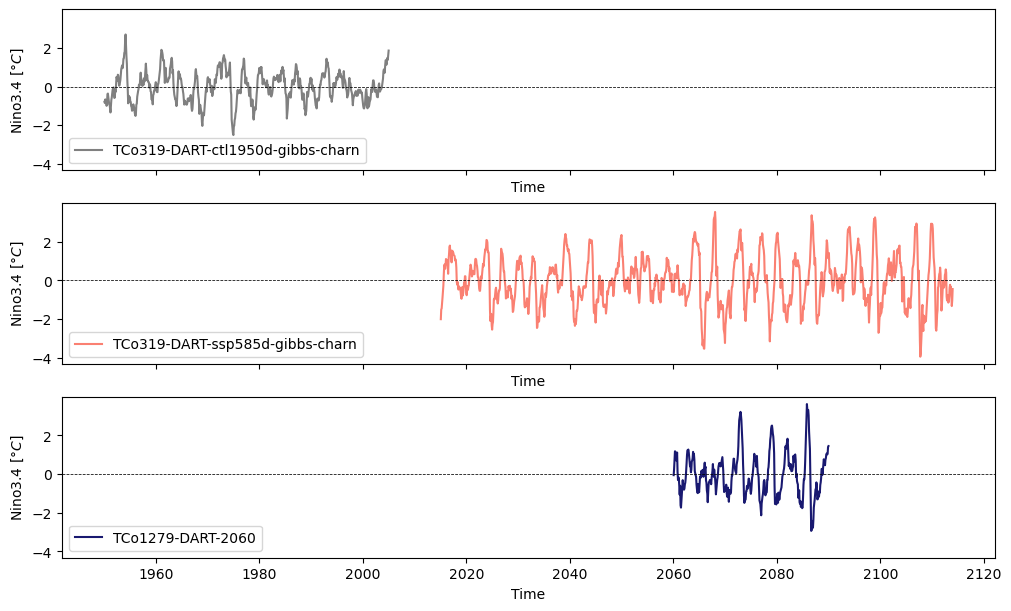

In [46]:
# Plot timeseries to check

fig,axs=plt.subplots(3,1,sharey=True,sharex=True,constrained_layout=True,figsize=(10,6))

for ex in range(nexp):
    ax = axs[ex]
    plotvar = enso_indices[ex]
    ax.plot(plotvar.time,plotvar,label=expnames[ex],c=expcolors[ex])
    ax.legend(loc='lower left')

    ax.set_xlabel("Time")
    ax.set_ylabel(r"Nino3.4 $[\degree C]$")
    ax.axhline([0],ls='dashed',c='k',lw=0.55)

#[ds.plot() for ds in enso_indices]
#plt.legend()

# Figure: Monthly Standard Deviation

Similar to Moon et al. 2025 Figure 17 Panels f-h

1. Compute standard deviation for anomalies of each month.
2. Visualize output as bar plot.

In [17]:
%%time

# Calculate Monthly Standard Deviation
monthly_stdev = [ds.groupby('time.month').std('time') for ds in enso_indices]

CPU times: user 23.5 ms, sys: 37 μs, total: 23.6 ms
Wall time: 22.6 ms


CPU times: user 279 ms, sys: 2.98 ms, total: 282 ms
Wall time: 280 ms


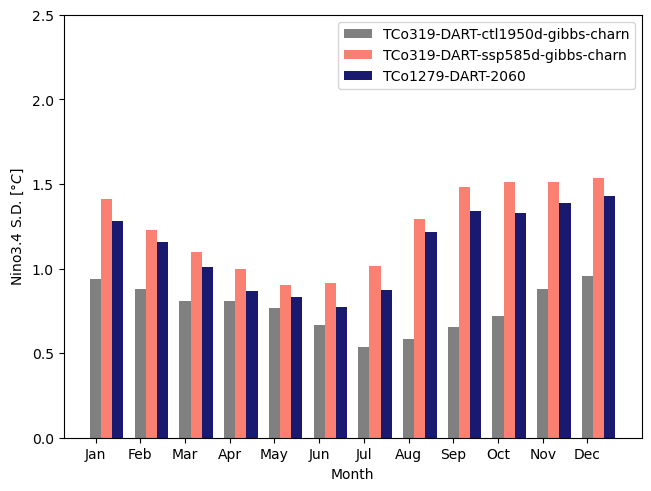

In [35]:
%%time
# Plotting Options
x            = np.arange(12)  # the label locations
width        = 0.25           # the width of the bars
plotex       = [0,1,2]        # Indices of Experiments to plot
mons3        = [cal.month_name[i][:3] for i in np.arange(1,13,1)] # Months for Labeling
label_bars   = False
# Other Edits

# Initialize Figure
fig,ax     = plt.subplots(1,1,layout='constrained')

# Loop for each Month
multiplier = 0
for im in range(12):
    offset = width * multiplier

    # Loop for each Experiment
    for ii in range(len(plotex)):

        # Setup
        offset      = width * ii
        color_in    = expcolors[ii]
        expid       = plotex[ii]
        if im == 0: # Label onlyon first iteration
            label=expnames[expid]
        else:
            label=""
        
        # Get Data and PLot
        measurement = monthly_stdev[expid].data
        rects  = ax.bar(x + offset, measurement, width, label=label,
                        color=color_in,linewidth=0.5)
        
        # Set Axis Ticks and option to label bars
        ax.set_xticks(x,mons3)
        if label_bars:
            ax.bar_label(rects, padding=3,fmt="%.02f")
        multiplier += 1

    # Axis Labeling and Legend
    ax.set_ylabel(r"Nino3.4 S.D. [$\degree C$]")
    ax.set_xlabel("Month")
    ax.set_ylim([0,2.5])
    ax.legend()

# Running Window Analysis for Standard Deviation and Persistence

1. Subset timeseries to N-year segments using running windows
2. Calculate standard deviation and persistence (lag-1 autocorrelation) for each segment.
3. Visualize the output

In [48]:
# Define Functions

def get_moving_segments(ts,winlen):
    '''
    Divide timeseries into segments using a sliding window of [winlen] months.
    
    Inputs
        ts (xr.DataArray)      : Target timeseries, with time dimension
        winlen (int)           : Number of months in sliding window
    Outputs
        ts_segments (np.array) : Sliding segments with dimensions  [segment_number,winlen]
        center_time (np.array) : Center time of the sliding window [segment_number]

    '''
    # Get Timeseries length and compute maximum number of segments
    ntime = len(ts)
    nsegments = ntime - winlen + 1
    
    # Take Segments
    ts_segments = np.zeros((nsegments,winlen))
    center_time = []#np.zeros((nsegments))
    for i in tqdm.tqdm(range(nsegments)):
        idseg = np.arange(i,i+winlen)
        ts_segments[i,:] = ts[idseg]
        center_time.append(ts.time.isel(time=int(i+ int(winlen/2))))
    # Concatenate center timesteps
    center_time = xr.concat(center_time,dim='time')
    return ts_segments,center_time

In [49]:
# (1)-(2) Subset into Segments, Take Moving Standard Deviation and Persistence

winlen       = 21*12
r1s          = []
stdevs       = [] 
ctimes_byexp = []
for ex in range(nexp):
    ts              = enso_indices[ex]
    segments,ctimes = get_moving_segments(ts,winlen)

    nsegments,ntime = segments.shape
    r1exp=[]
    for nn in tqdm.tqdm(range(nsegments)):
        r = np.corrcoef(segments[nn,:(ntime-1)],segments[nn,1:])[0,1]
        r1exp.append(r)
    r1s.append(np.array(r1exp))
    stdevs.append(np.std(segments,1))
    ctimes_byexp.append(ctimes)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 109/109 [00:00<00:00, 17291.85it/s]


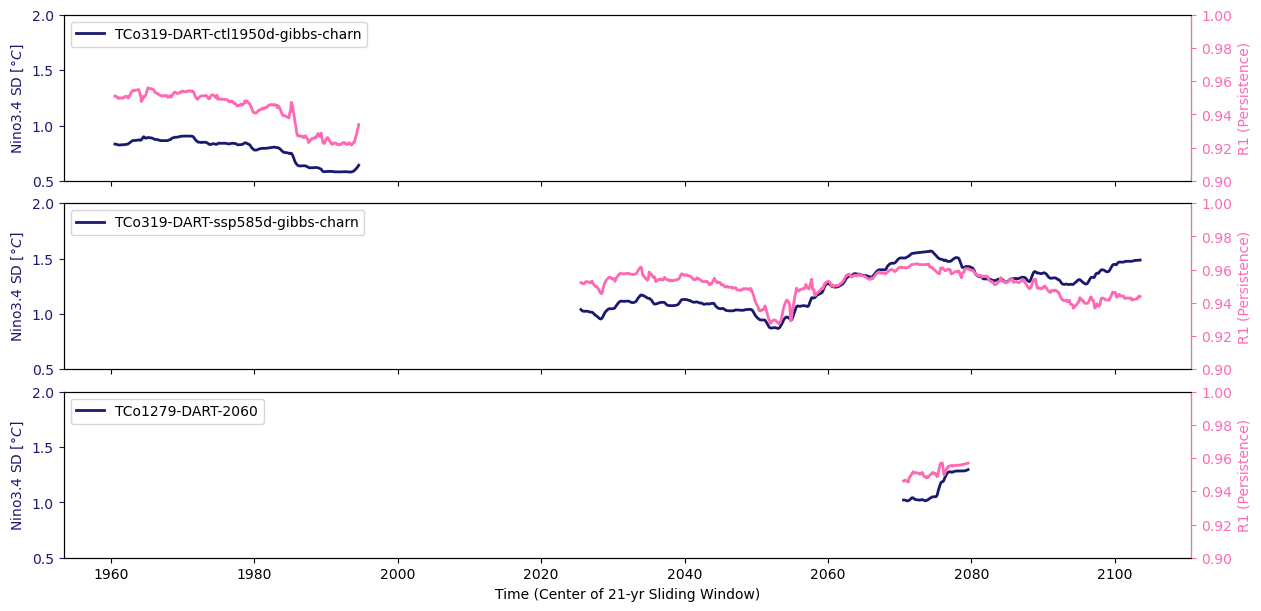

In [54]:
# Make a Plot

r1col = 'hotpink'
sdcol = 'midnightblue'

fig,axs = plt.subplots(nexp,1,figsize=(12.5,6),constrained_layout=True,sharex=True,)

for ii in range(nexp):
    ax      = axs[ii]
    ex      = ii
    
    plotvar = stdevs[ii]
    ctime   = ctimes_byexp[ii]
    
    ax.plot(ctime,plotvar,label=expnames[ex],lw=2,color=sdcol)

    ax2 = ax.twinx()
    plotvar2 = r1s[ii]
    ax2.plot(ctime,plotvar2,color=r1col,lw=2)
    ax2.set_ylim([.90,1.0])
    ax2.set_ylabel("R1 (Persistence)")

    ax2.tick_params(axis='y',colors=r1col)
    ax2.spines['right'].set_color(r1col)
    ax2.yaxis.label.set_color(r1col)
    
    
    ax.legend(loc='upper left')
    ax.set_ylim([0.5,2])
    ax.set_ylabel(r"Nino3.4 SD [$\degree C$]")

    ax.tick_params(axis='y',colors=sdcol)
    ax.spines['left'].set_color(sdcol)
    ax.yaxis.label.set_color(sdcol)
    if ii == 2:
        ax.set_xlabel("Time (Center of %i-yr Sliding Window)" % (winlen/12))
